# UCS420 Lab Assignment 9 — NLP Text Preprocessing
Enter your roll number and name, then run all cells.

In [1]:
ROLL_NO = 1024160123          # <-- your full roll number
NAME = "Khagendra Saini"            # <-- your name

import nltk
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
            "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    nltk.download(pkg, quiet=True)
assert ROLL_NO > 0 and NAME, "Enter your roll number and name first"

### Dataset generator — do not modify

In [2]:
import random, hashlib
import pandas as pd

def generate_dataset(roll_no):
    """Return (DataFrame of tickets, focus ticket IDs, fingerprint) for a roll number. Do not modify."""
    rng = random.Random(int(roll_no))

    subjects = [("LMS", ["LMS", "lms"]), ("Wi-Fi", ["Wi-Fi", "WiFi", "wifi"]), ("VPN", ["VPN"]),
                ("email", ["email", "e-mail"]), ("password", ["password"]), ("portal", ["student portal"]),
                ("projector", ["projector"]), ("laptop", ["laptop"]), ("MATLAB", ["MATLAB", "Matlab"]),
                ("Python", ["Python"]), ("printer", ["printer"]), ("server", ["server"])]
    actions = ["is not working", "keeps disconnecting", "failed to open", "is running slowly",
               "crashes while opening", "stopped responding", "is showing an error", "was working yesterday",
               "has stopped syncing", "keeps asking for login"]
    user_actions = ["cannot access", "can't open", "couldn't connect to", "am unable to use",
                    "tried restarting", "was locked out of", "keep getting logged out of", "reinstalled"]
    contexts = ["after resetting my password", "during the lab", "on my laptop", "since yesterday",
                "after the latest update", "when I use mobile hotspot", "before the assignment deadline",
                "while uploading the file", "after restarting the system", "when connected to campus Wi-Fi"]
    endings = ["Please help.", "Can you check this?", "I have tried several times!", "It worked yesterday.",
               "I don't know what changed.", "The same problem occurs again.", "Is there another solution?",
               "It works on another computer.", "This is urgent.", "Please resolve it."]
    challenges = {
        "negation": ["The Wi-Fi works, but the VPN doesn't.", "Why isn't the portal opening?",
                     "I can't login and I didn't change anything.", "It's not the laptop; it's the server.",
                     "Nothing works and nobody has replied.", "The printer won't print; it isn't jammed."],
        "numbers": ["Python 3.12 was installed yesterday.", "The file is 95.5% uploaded.",
                    "Error code 0x80070005 appears.", "I need Windows 11 by 5.30 p.m. today.",
                    "Only 2 of 30 PCs boot after 3.5 hours.", "Version 2.0.1 crashes at 99%."],
        "identifiers": ["Email me at helpdesk@university.edu.", "See https://lms.thapar.edu/help for details.",
                        "My roll no. is 1023-03-021.", "Ticket #4521 is still open.",
                        "Call me on +91 98765 43210 or 0175-239-3201.",
                        "Write to it.helpdesk@thapar.edu or visit www.thapar.edu/it."],
        "punctuation": ["I tried again... still no response!!!", "The LMS says 'Not Submitted'.",
                        "Dr. Rao's lab PC (No. 14) is down.", "Is it fixed?? Pls reply ASAP :(",
                        "The state-of-the-art lab (Lab-3) is closed.", "Re-installing didn't help; log-in still fails!"],
    }

    tickets = []
    for _ in range(8 + int(roll_no) % 5):
        _, variants = rng.choice(subjects)
        s = rng.choice(variants)
        template = rng.randrange(3)
        if template == 0:
            text = f"{s} {rng.choice(actions)} {rng.choice(contexts)}. {rng.choice(endings)}"
        elif template == 1:
            text = f"I {rng.choice(user_actions)} the {s} {rng.choice(contexts)}. {rng.choice(endings)}"
        else:
            text = f"The {s} {rng.choice(actions)}. {rng.choice(endings)}"
        tickets.append(text[0].upper() + text[1:])
    for category in ["negation", "numbers", "identifiers", "punctuation"]:
        tickets.append(rng.choice(challenges[category]))
    rng.shuffle(tickets)

    df = pd.DataFrame({"Ticket_ID": [f"T{i + 1:02d}" for i in range(len(tickets))], "Ticket_Text": tickets})
    focus = [f"T{i:02d}" for i in sorted(rng.sample(range(1, len(tickets) + 1), 2))]
    fingerprint = hashlib.md5(("|".join(tickets) + str(int(roll_no))).encode()).hexdigest()[:8].upper()
    return df, focus, fingerprint

### Preprocessing pipeline — do not modify

In [3]:
import string
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords

STOP = set(stopwords.words("english"))

def is_punct(token):
    """A token is punctuation if EVERY character in it is in string.punctuation (e.g. '.', '...', '``', "''")."""
    return all(ch in string.punctuation for ch in token)

def process_ticket(text):
    """The official pipeline. Returns sentences, lowercase tokens, punctuation, stopwords and final tokens."""
    sentences = sent_tokenize(text)
    tokens = [t.lower() for s in sentences for t in word_tokenize(s)]
    punct = [t for t in tokens if is_punct(t)]
    stops = [t for t in tokens if t in STOP]
    final = [t for t in tokens if not is_punct(t) and t not in STOP]
    return {"sentences": sentences, "tokens": tokens, "punct": punct, "stops": stops, "final": final}

In [4]:
df, FOCUS, FINGERPRINT = generate_dataset(ROLL_NO)
print(f"Roll number: {ROLL_NO}   Name: {NAME}   Fingerprint: {FINGERPRINT}   Tickets: {len(df)}\n")
print(df.to_string(index=False))
df.to_csv(f"{ROLL_NO}_generated_dataset.csv", index=False)

Roll number: 1024160123   Name: Khagendra Saini   Fingerprint: FA3FFB9D   Tickets: 15

Ticket_ID                                                                          Ticket_Text
      T01                                     The e-mail is running slowly. Please resolve it.
      T02 I can't open the password when connected to campus Wi-Fi. I don't know what changed.
      T03   I couldn't connect to the VPN while uploading the file. Is there another solution?
      T04                   WiFi keeps asking for login while uploading the file. Please help.
      T05              Server keeps asking for login after resetting my password. Please help.
      T06                                       Re-installing didn't help; log-in still fails!
      T07                      The projector is running slowly. The same problem occurs again.
      T08                                         Call me on +91 98765 43210 or 0175-239-3201.
      T09                                                 

---
## Q1. Preprocessing pipeline
Run process_ticket() on every ticket and show one table with, per ticket: sentences, tokens, punctuation tokens, stopwords, unique tokens and final tokens, plus a TOTAL row.

In [5]:
# Q1. Preprocessing

processed = {}

rows = []

for _, row in df.iterrows():
    result = process_ticket(row["Ticket_Text"])
    processed[row["Ticket_ID"]] = result

    rows.append({
        "Ticket_ID": row["Ticket_ID"],
        "Sentences": len(result["sentences"]),
        "Tokens": len(result["tokens"]),
        "Punctuation": len(result["punct"]),
        "Stopwords": len(result["stops"]),
        "Unique_Tokens": len(set(result["tokens"])),
        "Final_Tokens": len(result["final"])
    })

q1_table = pd.DataFrame(rows)

# Total row for count-based columns
total_row = {
    "Ticket_ID": "TOTAL",
    "Sentences": q1_table["Sentences"].sum(),
    "Tokens": q1_table["Tokens"].sum(),
    "Punctuation": q1_table["Punctuation"].sum(),
    "Stopwords": q1_table["Stopwords"].sum(),
    "Unique_Tokens": q1_table["Unique_Tokens"].sum(),
    "Final_Tokens": q1_table["Final_Tokens"].sum()
}

q1_table = pd.concat(
    [q1_table, pd.DataFrame([total_row])],
    ignore_index=True
)

display(q1_table)

selected_id = FOCUS[0]

selected = processed[selected_id]

print("Selected ticket:", selected_id)
print("Ticket text:")
print(df.loc[df["Ticket_ID"] == selected_id, "Ticket_Text"].iloc[0])

print("\nTokens:")
print(selected["tokens"])

print("\nPunctuation tokens:")
print(selected["punct"])

print("\nStopwords:")
print(selected["stops"])

print("\nFinal tokens:")
print(selected["final"])

,Ticket_ID,Sentences,Tokens,Punctuation,Stopwords,Unique_Tokens,Final_Tokens
0,T01,2,10,2,3,9,5
1,T02,2,19,2,7,16,10
2,T03,2,17,2,7,16,8
3,T04,2,13,2,3,12,8
4,T05,2,13,2,3,12,8
5,T06,1,9,2,1,9,6
6,T07,2,12,2,5,10,5
7,T08,1,9,1,3,9,5
8,T09,1,7,2,2,7,3
9,T10,2,11,2,4,10,5


Selected ticket: T13
Ticket text:
The Wi-Fi works, but the VPN doesn't.

Tokens:
['the', 'wi-fi', 'works', ',', 'but', 'the', 'vpn', 'does', "n't", '.']

Punctuation tokens:
[',', '.']

Stopwords:
['the', 'but', 'the', 'does']

Final tokens:
['wi-fi', 'works', 'vpn', "n't"]


**Observe:** Which final tokens in your data are not real words (e.g. n't, 's, ca)? Where do they come from?

*Your answer:*

---
## Q2. Regular expressions
On your raw tickets, use re.findall to extract: words longer than 5 letters; all numbers (keep 95.5 and 2.0.1 whole); capitalized words; words starting with a vowel. Then use re.sub to replace emails with <EMAIL>, URLs with <URL> and phone numbers with <PHONE>. Your patterns must also work on TEST_LINES (given in the notebook).

In [6]:
TEST_LINES = [
    "Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.",
    "Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.",
    "The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.",
]

import re
long_words_pattern = r"\b[A-Za-z]{6,}\b"
number_pattern = r"\b(?:0x[0-9A-Fa-f]+|\d+(?:\.\d+)+|\d+(?:,\d{3})*(?:\.\d+)?)\b"
capitalized_pattern = r"\b[A-Z][A-Za-z]*\b"
vowel_words_pattern = r"\b[AEIOUaeiou][A-Za-z]*\b"
email_pattern = r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b"
url_pattern = r"\b(?:https?://|www\.)[A-Za-z0-9.-]+(?:/[A-Za-z0-9._~:/?#\[\]@!$&'()*+,;=%-]*)?\b"
phone_pattern = r"(?<!\w)(?:\+\d{1,3}[- ]?)?(?:\d{3,5}[- ]\d{3,5}[- ]\d{4}|\d{10})(?!\w)"

regex_results = []

for _, row in df.iterrows():
    text = row["Ticket_Text"]

    regex_results.append({
        "Ticket_ID": row["Ticket_ID"],
        "Long_Words": re.findall(long_words_pattern, text),
        "Numbers": re.findall(number_pattern, text),
        "Capitalized_Words": re.findall(capitalized_pattern, text),
        "Vowel_Words": re.findall(vowel_words_pattern, text)
    })

regex_df = pd.DataFrame(regex_results)

display(regex_df)

print("=" * 80)
print("REGEX TEST_LINES")
print("=" * 80)

for i, line in enumerate(TEST_LINES, 1):
    print(f"\nTEST_LINE {i}:")
    print(line)
    print("Long words:",
          re.findall(long_words_pattern, line))
    print("Numbers:",
          re.findall(number_pattern, line))
    print("Capitalized words:",
          re.findall(capitalized_pattern, line))
    print("Vowel-starting words:",
          re.findall(vowel_words_pattern, line))

def replace_entities(text):
    text = re.sub(url_pattern, "<URL>", text)
    text = re.sub(email_pattern, "<EMAIL>", text)
    text = re.sub(phone_pattern, "<PHONE>", text)
    return text


print("\n" + "=" * 80)
print("REPLACED TICKETS")
print("=" * 80)

for _, row in df.iterrows():
    print(row["Ticket_ID"], ":", replace_entities(row["Ticket_Text"]))

print("\n" + "=" * 80)
print("REPLACED TEST_LINES")
print("=" * 80)

for line in TEST_LINES:
    print(replace_entities(line))

,Ticket_ID,Long_Words,Numbers,Capitalized_Words,Vowel_Words
0,T01,"[running, slowly, Please, resolve]",[],"[The, Please]","[e, is, it]"
1,T02,"[password, connected, campus, changed]",[],"[I, Wi, Fi, I]","[I, open, I]"
2,T03,"[couldn, connect, uploading, another, solution]",[],"[I, VPN, Is]","[I, uploading, Is, another]"
3,T04,"[asking, uploading, Please]",[],"[WiFi, Please]","[asking, uploading]"
4,T05,"[Server, asking, resetting, password, Please]",[],"[Server, Please]","[asking, after]"
5,T06,[installing],[],[Re],"[installing, in]"
6,T07,"[projector, running, slowly, problem, occurs]",[],"[The, The]","[is, occurs, again]"
7,T08,[],"[91, 98765, 43210, 0175, 239, 3201]",[Call],"[on, or]"
8,T09,[uploaded],[95.5],[The],"[is, uploaded]"
9,T10,"[laptop, showing, worked, yesterday]",[],"[The, It]","[is, an, error, It]"


REGEX TEST_LINES

TEST_LINE 1:
Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.
Long words: ['helpdesk', 'thapar', 'thapar', 'thapar']
Numbers: []
Capitalized words: ['Mail']
Vowel-starting words: ['it', 'edu', 'or', 'a', 'univ', 'ac', 'in', 'edu', 'or', 'edu', 'it']

TEST_LINE 2:
Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.
Long words: ['Version']
Numbers: ['91', '98765', '43210', '91', '98765', '43210', '0175', '239', '3201', '2.0.1', '95.5', '1,250']
Capitalized words: ['Call', 'Version', 'Rs']
Vowel-starting words: ['or', 'is']

TEST_LINE 3:
The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.
Long words: []
Numbers: ['5.30']
Capitalized words: ['The']
Vowel-starting words: ['of', 'art', 'isn', 'open', 'in', 'at']

REPLACED TICKETS
T01 : The e-mail is running slowly. Please resolve it.
T02 : I can't open the password when connected to campus Wi-Fi. I d

**Observe:** How many of your capitalized words are capitalized only because they start a sentence?

*Your answer:*

---
## Q3. Custom tokenizer
Write my_tokenize(text) with one RegexpTokenizer pattern that keeps contractions (isn't), hyphenated words (Wi-Fi, state-of-the-art), decimals and versions (95.5, 2.0.1), emails, URLs and phone numbers as single tokens. Run it on TEST_LINES and on your tickets, and compare with word_tokenize.

In [7]:
from nltk.tokenize import RegexpTokenizer

TOKEN_PATTERN = r"""
https?://[A-Za-z0-9.-]+(?:/[A-Za-z0-9._~:/?#\[\]@!$&'()*+,;=%-]*)?
|www\.[A-Za-z0-9.-]+(?:/[A-Za-z0-9._~:/?#\[\]@!$&'()*+,;=%-]*)?
|[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}
|\+\d{1,3}[- ]?\d{3,5}[- ]\d{3,5}[- ]\d{4}
|\d{3,5}[- ]\d{3,5}[- ]\d{4}
|\d+(?:\.\d+)+
|\d+(?:,\d{3})*(?:\.\d+)?
|[A-Za-z]+(?:'[A-Za-z]+)?
|[A-Za-z]+(?:-[A-Za-z]+)+
"""

my_tokenizer = RegexpTokenizer(TOKEN_PATTERN, flags=re.VERBOSE)


def my_tokenize(text):
    return my_tokenizer.tokenize(text)

print("=" * 80)
print("CUSTOM TOKENIZER ON TEST_LINES")
print("=" * 80)

for i, line in enumerate(TEST_LINES, 1):
    print(f"\nTEST_LINE {i}")
    print("Custom tokenizer:")
    print(my_tokenize(line))

    print("\nword_tokenize:")
    print(word_tokenize(line))

comparison_rows = []

for _, row in df.iterrows():
    text = row["Ticket_Text"]
    custom = my_tokenize(text)
    nltk_tokens = word_tokenize(text)
    comparison_rows.append({
        "Ticket_ID": row["Ticket_ID"],
        "Custom_Count": len(custom),
        "word_tokenize_Count": len(nltk_tokens),
        "Different": custom != nltk_tokens
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)
print(
    "\nNumber of tickets tokenized differently:",
    comparison_df["Different"].sum()
)
print("\n" + "=" * 80)
print("EXAMPLES OF DIFFERENCES")
print("=" * 80)

shown = 0

for _, row in df.iterrows():
    text = row["Ticket_Text"]

    custom = my_tokenize(text)
    nltk_tokens = word_tokenize(text)

    if custom != nltk_tokens:
        print("\nTicket:", row["Ticket_ID"])
        print("Text:", text)
        print("Custom:", custom)
        print("word_tokenize:", nltk_tokens)

        shown += 1

        if shown == 5:
            break

CUSTOM TOKENIZER ON TEST_LINES

TEST_LINE 1
Custom tokenizer:
['Mail', 'it.helpdesk@thapar.edu', 'or', 'a.b-c@dept.univ.ac.in', 'visit', 'https://lms.thapar.edu/help', 'or', 'www.thapar.edu/it.']

word_tokenize:
['Mail', 'it.helpdesk', '@', 'thapar.edu', 'or', 'a.b-c', '@', 'dept.univ.ac.in', ';', 'visit', 'https', ':', '//lms.thapar.edu/help', 'or', 'www.thapar.edu/it', '.']

TEST_LINE 2
Custom tokenizer:
['Call', '91', '98765', '43210', '91', '98765', '43210', 'or', '0175-239-3201', 'Version', '2.0.1', 'is', '95.5', 'done', 'fee', 'Rs', '1,250']

word_tokenize:
['Call', '+91', '98765', '43210', ',', '+91-98765-43210', 'or', '0175-239-3201', '.', 'Version', '2.0.1', 'is', '95.5', '%', 'done', ';', 'fee', 'Rs', '1,250', '.']

TEST_LINE 3
Custom tokenizer:
['The', 'state', 'of', 'the', 'art', 'lab', "isn't", 'open', 'log', 'in', 'at', '5.30', 'p', 'm', "didn't", 'work']

word_tokenize:
['The', 'state-of-the-art', 'lab', 'is', "n't", 'open', ';', 'log-in', 'at', '5.30', 'p.m.', 'did', "n

,Ticket_ID,Custom_Count,word_tokenize_Count,Different
0,T01,9,10,True
1,T02,16,19,True
2,T03,14,17,True
3,T04,11,13,True
4,T05,11,13,True
5,T06,8,9,True
6,T07,10,12,True
7,T08,8,9,True
8,T09,5,7,True
9,T10,9,11,True



Number of tickets tokenized differently: 15

EXAMPLES OF DIFFERENCES

Ticket: T01
Text: The e-mail is running slowly. Please resolve it.
Custom: ['The', 'e', 'mail', 'is', 'running', 'slowly', 'Please', 'resolve', 'it']
word_tokenize: ['The', 'e-mail', 'is', 'running', 'slowly', '.', 'Please', 'resolve', 'it', '.']

Ticket: T02
Text: I can't open the password when connected to campus Wi-Fi. I don't know what changed.
Custom: ['I', "can't", 'open', 'the', 'password', 'when', 'connected', 'to', 'campus', 'Wi', 'Fi', 'I', "don't", 'know', 'what', 'changed']
word_tokenize: ['I', 'ca', "n't", 'open', 'the', 'password', 'when', 'connected', 'to', 'campus', 'Wi-Fi', '.', 'I', 'do', "n't", 'know', 'what', 'changed', '.']

Ticket: T03
Text: I couldn't connect to the VPN while uploading the file. Is there another solution?
Custom: ['I', "couldn't", 'connect', 'to', 'the', 'VPN', 'while', 'uploading', 'the', 'file', 'Is', 'there', 'another', 'solution']
word_tokenize: ['I', 'could', "n't", 'conn

**Observe:** How many of your tickets are tokenized differently by my_tokenize and word_tokenize?

*Your answer:*

---
## Q4. Stemming and lemmatization
On your unique final tokens, compare PorterStemmer, LancasterStemmer, a RegexpStemmer with a suffix rule you choose after looking at your own words, and WordNetLemmatizer with POS tags from nltk.pos_tag. Show a table of the words where the outputs differ.

In [8]:
from nltk.stem import PorterStemmer, LancasterStemmer, RegexpStemmer
from nltk.stem import WordNetLemmatizer

porter = PorterStemmer()
lancaster = LancasterStemmer()
lemmatizer = WordNetLemmatizer()

def penn_to_wordnet(tag):
    if tag.startswith("J"):
        return "a"       # adjective
    elif tag.startswith("V"):
        return "v"       # verb
    elif tag.startswith("N"):
        return "n"       # noun
    elif tag.startswith("R"):
        return "r"       # adverb
    else:
        return "n"

unique_final_tokens = sorted(
    set(
        token
        for result in processed.values()
        for token in result["final"]
    )
)

suffix_candidates = {}

for suffix in ["ing", "ed", "ly", "es", "s"]:
    words = [
        word for word in unique_final_tokens
        if word.endswith(suffix) and len(word) > len(suffix) + 2
    ]
    suffix_candidates[suffix] = words

print("Suffix candidates:")
for suffix, words in suffix_candidates.items():
    print(f"{suffix}: {words}")

regexp_stemmer = RegexpStemmer("ing$")

pos_tags = dict(
    nltk.pos_tag(unique_final_tokens)
)

stem_rows = []

for word in unique_final_tokens:

    porter_result = porter.stem(word)
    lancaster_result = lancaster.stem(word)
    regexp_result = regexp_stemmer.stem(word)

    wn_pos = penn_to_wordnet(pos_tags[word])
    lemma_result = lemmatizer.lemmatize(word, pos=wn_pos)

    stem_rows.append({
        "Word": word,
        "Porter": porter_result,
        "Lancaster": lancaster_result,
        "Regexp": regexp_result,
        "POS": pos_tags[word],
        "Lemma": lemma_result
    })


stem_df = pd.DataFrame(stem_rows)

output_columns = ["Porter", "Lancaster", "Regexp", "Lemma"]

different_df = stem_df[
    stem_df[output_columns].nunique(axis=1) > 1
].copy()

display(different_df)

print("\nRegexp Stemmer choice:")
print(
    "The suffix 'ing' was selected because the dataset contains "
    "multiple words ending in -ing, such as working, uploading, "
    "reinstalling and resetting. Removing -ing demonstrates a "
    "simple rule-based stemming operation."
)

print("\nExamples where stemming differs from the original:")
print(
    stem_df[
        (stem_df["Porter"] != stem_df["Word"]) |
        (stem_df["Lancaster"] != stem_df["Word"])
    ][["Word", "Porter", "Lancaster", "Regexp", "Lemma"]]
    .head(15)
)

Suffix candidates:
ing: ['asking', 're-installing', 'resetting', 'responding', 'running', 'showing', 'uploading', 'working']
ed: ['changed', 'connected', 'reinstalled', 'stopped', 'uploaded', 'worked']
ly: ['slowly']
es: []
s: ['campus', 'fails', 'keeps', 'occurs', 'works']


,Word,Porter,Lancaster,Regexp,POS,Lemma
5,another,anoth,anoth,another,DT,another
8,call,call,cal,call,VB,call
9,campus,campu,camp,campus,NN,campus
10,changed,chang,chang,changed,VBN,change
12,connected,connect,connect,connected,VBN,connect
15,error,error,er,error,NN,error
16,fails,fail,fail,fails,VBZ,fail
17,file,file,fil,file,NN,file
20,keeps,keep,keep,keeps,NNS,keep
23,lms,lm,lms,lms,NNS,lm



Regexp Stemmer choice:
The suffix 'ing' was selected because the dataset contains multiple words ending in -ing, such as working, uploading, reinstalling and resetting. Removing -ing demonstrates a simple rule-based stemming operation.

Examples where stemming differs from the original:
         Word   Porter Lancaster     Regexp    Lemma
5     another    anoth     anoth    another  another
6      asking      ask       ask        ask      ask
8        call     call       cal       call     call
9      campus    campu      camp     campus   campus
10    changed    chang     chang    changed   change
12  connected  connect   connect  connected  connect
15      error    error        er      error    error
16      fails     fail      fail      fails     fail
17       file     file       fil       file     file
20      keeps     keep      keep      keeps     keep
23        lms       lm       lms        lms       lm
26     mobile    mobil      mobl     mobile   mobile
28     occurs    occur

**Observe:** Give one over-stemming and one under-stemming example from your table.

*Your answer:*

---
## Q5. Corpus statistics
Compute tokens, unique tokens and TTR for S1 (all tokens), S2 (no punctuation), S3 (final tokens) and S4 (S3 after Porter). Print the top 10 words of S1 and S3, plot log(rank) vs log(frequency) for S3, and print the top 5 bigrams of S1 and S3.

,Total Tokens,Unique Tokens,TTR
S1,184.0,88.0,0.478261
S2,155.0,82.0,0.529032
S3,94.0,58.0,0.617021
S4,94.0,54.0,0.574468


TOP 10 WORDS — S1
.                    23
the                  14
is                   7
i                    7
n't                  6
please               4
when                 4
to                   4
wi-fi                4
help                 4

TOP 10 WORDS — S3
n't                  6
please               4
wi-fi                4
help                 4
connected            3
campus               3
file                 3
running              2
slowly               2
password             2


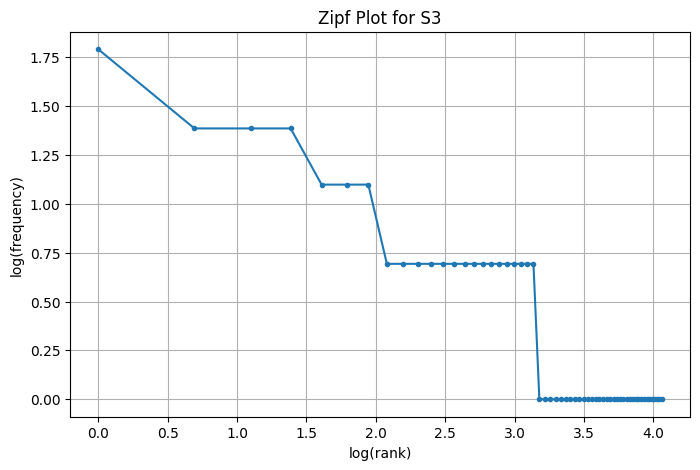

TOP 5 BIGRAMS — S1
('.', 'i') : 6
('.', 'the') : 5
('.', 'please') : 4
('when', 'connected') : 3
('connected', 'to') : 3

TOP 5 BIGRAMS — S3
('connected', 'campus') : 3
('campus', 'wi-fi') : 3
('please', 'help') : 3
('running', 'slowly') : 2
("n't", 'know') : 2


In [9]:
from collections import Counter
from nltk.util import ngrams
import matplotlib.pyplot as plt
import numpy as np

S1 = []
S2 = []
S3 = []

for result in processed.values():
    S1.extend(result["tokens"])
    S2.extend([t for t in result["tokens"] if not is_punct(t)])
    S3.extend(result["final"])

S4 = [porter.stem(token) for token in S3]

def corpus_stats(tokens):
    total = len(tokens)
    unique = len(set(tokens))
    ttr = unique / total if total else 0

    return {
        "Total Tokens": total,
        "Unique Tokens": unique,
        "TTR": ttr
    }


stats_df = pd.DataFrame({
    "S1": corpus_stats(S1),
    "S2": corpus_stats(S2),
    "S3": corpus_stats(S3),
    "S4": corpus_stats(S4)
}).T

display(stats_df)

print("=" * 80)
print("TOP 10 WORDS — S1")
print("=" * 80)

s1_counts = Counter(S1)

for word, freq in s1_counts.most_common(10):
    print(f"{word:20s} {freq}")


print("\n" + "=" * 80)
print("TOP 10 WORDS — S3")
print("=" * 80)

s3_counts = Counter(S3)

for word, freq in s3_counts.most_common(10):
    print(f"{word:20s} {freq}")

frequencies = sorted(
    s3_counts.values(),
    reverse=True
)

ranks = np.arange(1, len(frequencies) + 1)

log_ranks = np.log(ranks)
log_frequencies = np.log(frequencies)

plt.figure(figsize=(8, 5))
plt.plot(log_ranks, log_frequencies, marker="o", markersize=3)
plt.xlabel("log(rank)")
plt.ylabel("log(frequency)")
plt.title("Zipf Plot for S3")
plt.grid(True)
plt.show()

s1_bigrams = Counter(ngrams(S1, 2))
s3_bigrams = Counter(ngrams(S3, 2))


print("=" * 80)
print("TOP 5 BIGRAMS — S1")
print("=" * 80)

for bigram, freq in s1_bigrams.most_common(5):
    print(bigram, ":", freq)


print("\n" + "=" * 80)
print("TOP 5 BIGRAMS — S3")
print("=" * 80)

for bigram, freq in s3_bigrams.most_common(5):
    print(bigram, ":", freq)

**Observe:** Why does TTR change from S1 to S4 in your data?

*Your answer:*